# Shape Comparison Before vs After Preprocessing

## What is Shape Comparison?

Shape comparison means comparing the **number of rows and columns** in a dataset before and after preprocessing.

In Pandas, the shape of a DataFrame is represented as:

```text
(rows, columns)
```

For example:

```text
(1000, 8)
```

means the dataset contains:

* 1000 rows
* 8 columns

After preprocessing, the shape may change depending on the techniques used.

## Why is Shape Comparison Required?

Shape comparison helps us verify whether preprocessing changed the dataset as expected.

For example:

* Removing duplicate rows decreases the number of rows.
* Removing unnecessary features decreases the number of columns.
* One-Hot Encoding can increase the number of columns.
* Imputation normally does not change the number of rows or columns.
* Scaling normally does not change the number of rows or columns.

This helps an AI/ML engineer detect unexpected changes in the dataset.


## What Does the Python Example Tell Us?

Before preprocessing, the dataset has:

```text
4 rows × 2 columns
```

The columns are:

```text
Age
City
```

After One-Hot Encoding, the `City` column is converted into three numerical columns:

```text
City_Bangalore
City_Chennai
City_Mumbai
```

Therefore, the dataset becomes:

```text
4 rows × 4 columns
```

The **number of rows did not change**, but the **number of columns increased from 2 to 4**.

This shows that preprocessing can change the shape of a dataset.

## AI/ML Example

Suppose we are building a customer churn prediction model.

Before preprocessing:

```text
Age
Salary
City
```

After encoding `City`:

```text
Age
Salary
City_Bangalore
City_Chennai
City_Mumbai
```

The feature count increases because one categorical feature is converted into multiple numerical features.

## Business Example

A company wants to predict whether customers will purchase a product.

The dataset contains:

```text
Age
Income
City
```

If `City` contains 10 different categories, One-Hot Encoding can create 10 separate features.

Therefore, checking the shape before and after preprocessing helps the company understand how the dataset structure changed.

## AI/ML Engineer Use Case

An AI/ML engineer checks dataset shape after preprocessing to make sure the pipeline produced the expected number of features.

For example:

```text
Before preprocessing → (100000, 20)
After preprocessing  → (100000, 45)
```

If the engineer expected 45 features but receives 200 features, it may indicate an encoding or preprocessing problem.

Shape comparison is therefore an important validation step before passing the processed data to a machine learning model.


In [2]:

## Python Example

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Original dataset
df = pd.DataFrame({
    "Age": [25, 30, 35, 40],
    "City": ["Chennai", "Bangalore", "Chennai", "Mumbai"]
})

print("Before preprocessing:", df.shape)

# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)
city_encoded = encoder.fit_transform(df[["City"]])

# Convert encoded values into DataFrame
encoded_df = pd.DataFrame(
    city_encoded,
    columns=encoder.get_feature_names_out(["City"])
)

# Combine numerical feature with encoded features
df_after = pd.concat(
    [df[["Age"]], encoded_df],
    axis=1
)

print("After preprocessing:", df_after.shape)
print("\nProcessed dataset:")
print(df_after)


Before preprocessing: (4, 2)
After preprocessing: (4, 4)

Processed dataset:
   Age  City_Bangalore  City_Chennai  City_Mumbai
0   25             0.0           1.0          0.0
1   30             1.0           0.0          0.0
2   35             0.0           1.0          0.0
3   40             0.0           0.0          1.0


# Data Types Comparison Before vs After Preprocessing

## What is Data Types Comparison?

Data types comparison means checking the **data type of each feature before and after preprocessing**.

Common Pandas data types include:

* `int64` → Integer numbers
* `float64` → Decimal numbers
* `object` → Usually text/categorical data
* `bool` → True/False values

During preprocessing, data types may change. For example, categorical text values can be converted into numerical values using encoding.

## Why is Data Types Comparison Required?

Machine learning algorithms generally work with numerical input.

For example:

```text
City
Chennai
Bangalore
Mumbai
```

cannot be directly given to many ML algorithms.

After encoding:

```text
City_Chennai
City_Bangalore
City_Mumbai
```

the categorical information becomes numerical.

Comparing data types helps an AI/ML engineer verify that the processed features have the expected format.

## What Does the Python Example Tell Us?

Before preprocessing:

```text
Age  → int64
City → object
```

The `City` column contains text values, so its data type is `object`.

After preprocessing:

```text
Age  → int64
City → int64
```

The categorical `City` values were converted into numerical values.

Therefore, the comparison shows that preprocessing changed the `City` feature from a **categorical text type to a numerical type**.

## AI/ML Example

Suppose we are building a customer churn prediction model.

Before preprocessing:

```text
Age       → int64
Salary    → float64
City      → object
Churn     → object
```

After preprocessing:

```text
Age       → numerical
Salary    → numerical
City      → numerical
Churn     → numerical
```

Now the features are in a form that can be processed by the ML model.

## Business Example

A bank wants to predict whether a customer will default on a loan.

The original dataset may contain:

```text
Employment_Type → "Salaried"
                 "Business"
                 "Self-Employed"
```

These are categorical values.

After encoding, they become numerical values that can be used by the loan prediction model.

## AI/ML Engineer Use Case

An AI/ML engineer checks data types before model training to identify problems such as:

```text
object columns remaining unexpectedly
```

For example, if the final training dataset still contains:

```text
Gender → object
City   → object
```

the engineer knows that categorical preprocessing may not have been applied correctly.

Therefore, comparing data types before and after preprocessing helps verify that the preprocessing pipeline has produced model-ready data.


In [3]:

## Python Example

import pandas as pd

# Original dataset
df = pd.DataFrame({
    "Age": [25, 30, 35],
    "City": ["Chennai", "Bangalore", "Mumbai"]
})

print("Before preprocessing:")
print(df.dtypes)

# Convert categorical City column into numerical codes
df["City"] = df["City"].map({
    "Chennai": 0,
    "Bangalore": 1,
    "Mumbai": 2
})

print("\nAfter preprocessing:")
print(df.dtypes)

print("\nProcessed dataset:")
print(df)

Before preprocessing:
Age      int64
City    object
dtype: object

After preprocessing:
Age     int64
City    int64
dtype: object

Processed dataset:
   Age  City
0   25     0
1   30     1
2   35     2


# Missing Values Comparison Before vs After Preprocessing

## What are Missing Values?

Missing values are data points where information is not available.

In Pandas, missing values are commonly represented as:

```text
NaN
```

For example:

```text
Age
25
30
NaN
40
```

Here, the third row has a missing value in the `Age` column.

## Why is Missing Value Comparison Required?

Most machine learning algorithms cannot directly work with missing values.

Therefore, preprocessing techniques such as **imputation** are used to replace missing values.

Comparing missing values before and after preprocessing helps us verify that missing data was handled correctly.

For example:

```text
Before → Age contains 1 missing value
After  → Age contains 0 missing values


## What Does the Python Example Tell Us?

Before preprocessing:

```text
Age       → 1 missing value
Salary    → 1 missing value
```

The `SimpleImputer` with `strategy="mean"` calculates the mean of each column and uses it to replace the missing value.

After preprocessing:

```text
Age       → 0 missing values
Salary    → 0 missing values
```

Therefore, the comparison confirms that the missing values were successfully handled.

## AI/ML Example

Suppose we are building a house price prediction model.

The dataset contains:

```text
Area
Bedrooms
Age
Price
```

Some `Area` and `Age` values are missing.

Before training the model:

```text
Missing values → Must be handled
```

After imputation:

```text
Missing values → 0
```

The cleaned data can then be passed to the ML model.

## Business Example

A bank uses customer information to predict loan approval.

Some customers may have missing:

* Income
* Age
* Credit history

The bank can use appropriate imputation techniques to handle missing values before model training.

Comparing missing values before and after preprocessing confirms that the missing data has been handled.

## AI/ML Engineer Use Case

An AI/ML engineer checks missing values before and after preprocessing as a validation step.

For example:

```text
Before preprocessing → 250 missing values
After preprocessing  → 0 missing values
```

If missing values still remain unexpectedly, the engineer needs to investigate the preprocessing pipeline.

Therefore, missing-value comparison helps ensure that the dataset is clean and ready for machine learning.


In [4]:

## Python Example

import pandas as pd
from sklearn.impute import SimpleImputer

# Dataset with missing values
df = pd.DataFrame({
    "Age": [25, 30, None, 40],
    "Salary": [30000, None, 50000, 60000]
})

print("Missing values before preprocessing:")
print(df.isnull().sum())

# Impute missing values using the column mean
imputer = SimpleImputer(strategy="mean")
df[["Age", "Salary"]] = imputer.fit_transform(df[["Age", "Salary"]])

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nProcessed dataset:")
print(df)


#The exact decimal formatting may vary slightly depending on the display settings.

Missing values before preprocessing:
Age       1
Salary    1
dtype: int64

Missing values after preprocessing:
Age       0
Salary    0
dtype: int64

Processed dataset:
         Age        Salary
0  25.000000  30000.000000
1  30.000000  46666.666667
2  31.666667  50000.000000
3  40.000000  60000.000000


# Duplicates Comparison Before vs After Preprocessing

## What are Duplicates?

Duplicates are rows that contain the same values across the columns.

For example:

```text
   Name    Age    City
0  Arun    25     Chennai
1  Priya   30     Mumbai
2  Arun    25     Chennai
```

Here, rows 0 and 2 are duplicates.

## Why is Duplicate Comparison Required?

Duplicate records can cause the same observation to appear multiple times in the dataset.

This can:

* Increase the importance of repeated records.
* Affect statistical analysis.
* Bias machine learning models.
* Increase the dataset size unnecessarily.

Therefore, duplicates should be checked before and after preprocessing.


## What Does the Python Example Tell Us?

Before preprocessing:

```text
Duplicates → 1
```

There is one duplicate row because the `Arun` record appears twice.

The `drop_duplicates()` method removes the duplicate row.

After preprocessing:

```text
Duplicates → 0
```

The dataset now contains only unique records.

The number of rows also decreases from **4 to 3**.

## AI/ML Example

Suppose we are building a customer churn prediction model.

If the same customer appears multiple times with exactly the same information, the model may give extra importance to that customer.

Removing exact duplicate records helps prevent this unnecessary repetition.

## Business Example

An e-commerce company has customer transaction data.

The same transaction may accidentally be recorded twice because of a system or data-loading problem.

For example:

```text
Transaction ID: 1001
Amount: ₹5,000
```

appears twice.

Removing duplicate records prevents the business from incorrectly counting the transaction twice.

## AI/ML Engineer Use Case

An AI/ML engineer checks duplicate rows before model training.

For example:

```text
Before preprocessing → 10,000 rows
Duplicate rows       → 350
After removing       → 9,650 rows
```

The engineer can then verify that the reduction in row count is expected.

Duplicate comparison is therefore an important data-quality check before training a machine learning model.


In [5]:

## Python Example

import pandas as pd

# Dataset containing duplicate rows
df = pd.DataFrame({
    "Name": ["Arun", "Priya", "Arun", "Kumar"],
    "Age": [25, 30, 25, 35],
    "City": ["Chennai", "Mumbai", "Chennai", "Bangalore"]
})

# Check duplicates before preprocessing
print("Duplicates before preprocessing:")
print(df.duplicated().sum())

# Remove duplicate rows
df_after = df.drop_duplicates()

# Check duplicates after preprocessing
print("\nDuplicates after preprocessing:")
print(df_after.duplicated().sum())

print("\nDataset after preprocessing:")
print(df_after)


Duplicates before preprocessing:
1

Duplicates after preprocessing:
0

Dataset after preprocessing:
    Name  Age       City
0   Arun   25    Chennai
1  Priya   30     Mumbai
3  Kumar   35  Bangalore


# Outliers Comparison Before vs After Preprocessing

## What are Outliers?

Outliers are values that are **very different from most other values** in a dataset.

For example, consider these salaries:

```text
30000
35000
40000
45000
1000000
```

`1000000` is much larger than the other values and may be an outlier.

## Why is Outlier Comparison Required?

Outliers can affect:

* Mean and standard deviation
* Data distributions
* Statistical analysis
* Some machine learning algorithms
* Model performance

Therefore, we compare outliers before and after preprocessing to check whether they were handled correctly.

Important: **Scaling does not remove outliers.** An outlier-handling technique such as IQR-based removal, capping, or `RobustScaler` must be used if the goal is to reduce their impact.

## What Does the Python Example Tell Us?

Before preprocessing:

```text id="n0r3zx"
Outliers → 1
```

The value `1000000` is identified as an outlier using the **IQR method**.

The outlier is removed from the dataset.

After preprocessing:

```text id="qk5c2u"
Outliers → 0
```

The comparison confirms that the outlier-handling step successfully removed the identified outlier.

The number of rows also changed from **5 to 4** because one outlier was removed.

## AI/ML Example

Suppose we are building a salary prediction model.

Most salaries are between ₹30,000 and ₹50,000, but one record contains ₹10,00,00,000 because of a data-entry error.

That extreme value can negatively affect the model.

An AI/ML engineer can detect and handle the outlier before training.

## Business Example

A retail company analyzes customer purchase amounts.

Most customers spend between ₹500 and ₹10,000, but one transaction shows ₹50,00,000 due to an incorrect data entry.

Outlier analysis can identify the suspicious value so that it can be investigated or handled appropriately.

## AI/ML Engineer Use Case

An AI/ML engineer compares outliers before and after preprocessing to verify the preprocessing pipeline.

For example:

```text id="0j0qj4"
Before preprocessing → 125 outliers
After preprocessing  → 8 outliers
```

The remaining 8 outliers may be legitimate observations and should not automatically be removed.

Therefore, outlier comparison helps an AI/ML engineer understand whether extreme values were **removed, capped, transformed, or intentionally retained**.


In [6]:

## Python Example

import pandas as pd

# Dataset containing an outlier
df = pd.DataFrame({
    "Salary": [30000, 35000, 40000, 45000, 1000000]
})

# Calculate IQR
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers before preprocessing
outliers_before = (
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
).sum()

# Remove outliers
df_after = df[
    (df["Salary"] >= lower_bound) &
    (df["Salary"] <= upper_bound)
]

# Count outliers after preprocessing
Q1_after = df_after["Salary"].quantile(0.25)
Q3_after = df_after["Salary"].quantile(0.75)
IQR_after = Q3_after - Q1_after

lower_after = Q1_after - 1.5 * IQR_after
upper_after = Q3_after + 1.5 * IQR_after

outliers_after = (
    (df_after["Salary"] < lower_after) |
    (df_after["Salary"] > upper_after)
).sum()

print("Outliers before preprocessing:", outliers_before)
print("Outliers after preprocessing:", outliers_after)

print("\nSalary values after preprocessing:")
print(df_after)


Outliers before preprocessing: 1
Outliers after preprocessing: 0

Salary values after preprocessing:
   Salary
0   30000
1   35000
2   40000
3   45000


# Distribution Comparison Before vs After Preprocessing

## What is Distribution Comparison?

Distribution comparison means comparing how numerical values are **spread across the dataset** before and after preprocessing.

For example, a salary feature may contain values ranging from ₹20,000 to ₹1,00,000 before preprocessing.

After a transformation or scaling technique, the values may have a different scale or shape.

Distribution comparison helps us understand whether preprocessing changed the data and how.

## Why is Distribution Comparison Required?

Some preprocessing techniques can change the distribution of data.

For example:

* **Standardization** changes the scale but generally preserves the distribution shape.
* **Min-Max Scaling** changes the range of values.
* **Log Transformation** can reduce right skewness.
* **Power Transformation** can make a distribution more symmetric.

Comparing distributions helps an AI/ML engineer verify whether the preprocessing technique produced the expected result.


## What Does the Python Example Tell Us?

Before preprocessing, the salary values are in their original scale:

```text
30000, 35000, 40000, 45000, 50000
```

After applying `StandardScaler`, the values are transformed to a standardized scale.

The important point is:

```text
Before → Original numerical scale
After  → Standardized numerical scale
```

Standardization changes the **scale of the values**, but it generally does not change the underlying distribution shape.

The histogram allows us to visually compare both distributions.

## AI/ML Example

Suppose we are building a house price prediction model.

The `Area` feature may contain values such as:

```text
500
1000
1500
2000
```

while `Price` may contain:

```text
2000000
5000000
8000000
```

After scaling, both features are brought to comparable numerical scales.

Distribution comparison helps verify that the transformation was applied correctly.

## Business Example

An e-commerce company analyzes customer spending.

The spending distribution may be highly skewed because a small number of customers spend much more than average.

The company can apply a transformation such as log transformation and compare the distributions before and after to see whether the skewness has been reduced.

## AI/ML Engineer Use Case

An AI/ML engineer compares feature distributions before and after preprocessing to detect unexpected changes.

For example:

```text
Before → Highly skewed salary distribution
After  → More balanced distribution
```

This is particularly useful when using transformations such as **log transformation, power transformation, or Yeo-Johnson transformation**.

Distribution comparison therefore helps confirm whether preprocessing has changed the data in the expected way and whether the resulting features are more suitable for machine learning.


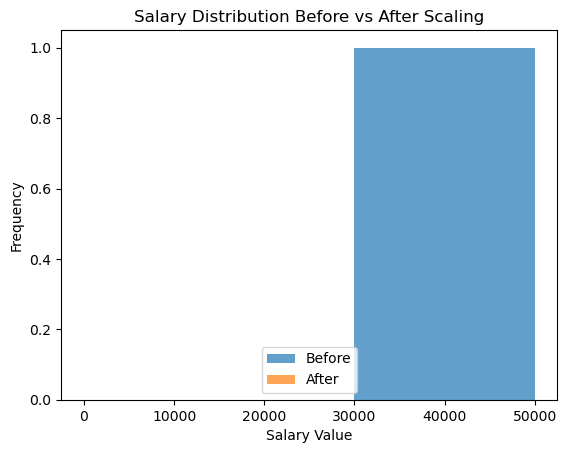

In [8]:

## Python Example

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Original dataset
df = pd.DataFrame({
    "Salary": [30000, 35000, 40000, 45000, 50000]
})

# Scale the numerical feature
scaler = StandardScaler()
df["Salary_scaled"] = scaler.fit_transform(df[["Salary"]])

# Compare distributions
plt.hist(df["Salary"], bins=5, alpha=0.7, label="Before")
plt.hist(df["Salary_scaled"], bins=5, alpha=0.7, label="After")

plt.title("Salary Distribution Before vs After Scaling")
plt.xlabel("Salary Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Categorical Values Comparison Before vs After Preprocessing

## What is Categorical Values Comparison?

Categorical values are values that represent groups or categories.

For example:

```text
City
Chennai
Bangalore
Mumbai
Chennai
```

Before preprocessing, categorical values are usually stored as text.

During preprocessing, categorical features can be converted into numerical values using techniques such as:

* One-Hot Encoding
* Ordinal Encoding
* Label Encoding

Comparing categorical values before and after preprocessing helps us verify how categorical information was transformed.

## Why is Categorical Values Comparison Required?

Machine learning algorithms generally require numerical input.

For example, a model cannot directly perform mathematical calculations on:

```text
Chennai
Bangalore
Mumbai
```

Therefore, categorical values need to be encoded.

By comparing before and after preprocessing, we can verify that:

```text
Before → Categorical text values
After  → Numerical encoded features

## What Does the Python Example Tell Us?

Before preprocessing, the `City` column contains three categorical values:

```text
Chennai
Bangalore
Mumbai
```

After applying One-Hot Encoding, the single `City` column becomes three numerical features:

```text
City_Bangalore
City_Chennai
City_Mumbai
```

For example:

```text
Chennai → [0, 1, 0]
Bangalore → [1, 0, 0]
Mumbai → [0, 0, 1]
```

Therefore, categorical information is preserved but represented in a numerical format that can be used by machine learning algorithms.

## AI/ML Example

Suppose we are building a customer churn prediction model.

The dataset contains:

```text
Customer_ID
Age
City
Salary
```

Before preprocessing:

```text
City → Chennai, Bangalore, Mumbai
```

After One-Hot Encoding:

```text
City_Chennai
City_Bangalore
City_Mumbai
```

The model can now use these numerical features as input.

## Business Example

An e-commerce company wants to predict whether a customer will purchase a product.

One feature is:

```text
Payment_Method
```

It contains:

```text
Credit Card
UPI
Net Banking
```

These categories can be encoded into numerical features before training the prediction model.

## AI/ML Engineer Use Case

An AI/ML engineer compares categorical values before and after preprocessing to verify that:

```text
Original category → Correct encoded feature
```

For example:

```text
Before:
City → Chennai, Bangalore, Mumbai

After:
City_Chennai
City_Bangalore
City_Mumbai
```

The engineer can also check whether unexpected categories appeared or whether important categories were accidentally removed.

Categorical value comparison is therefore an important validation step for preprocessing pipelines that contain categorical encoding.


In [9]:
## Python Example

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Original dataset
df = pd.DataFrame({
    "City": ["Chennai", "Bangalore", "Mumbai", "Chennai"]
})

print("Categorical values before preprocessing:")
print(df["City"].unique())

# Apply One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[["City"]])

# Create DataFrame with encoded values
df_after = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["City"])
)

print("\nCategorical values after preprocessing:")
print(df_after)


Categorical values before preprocessing:
['Chennai' 'Bangalore' 'Mumbai']

Categorical values after preprocessing:
   City_Bangalore  City_Chennai  City_Mumbai
0             0.0           1.0          0.0
1             1.0           0.0          0.0
2             0.0           0.0          1.0
3             0.0           1.0          0.0


# Numerical Ranges Comparison Before vs After Preprocessing

## What is Numerical Range Comparison?

Numerical range comparison means comparing the **minimum and maximum values of numerical features** before and after preprocessing.

For example, a `Salary` feature may have values between:

```text
30000 to 1000000
```

After applying Min-Max Scaling, the values are transformed to a range between:

```text
0 to 1
```

Comparing numerical ranges helps us understand how preprocessing changed the scale of numerical features.

## Why is Numerical Range Comparison Required?

Different numerical features can have very different ranges.

For example:

```text
Age       → 20 to 60
Salary    → 20,000 to 1,000,000
Experience → 0 to 20
```

Some machine learning algorithms are sensitive to feature scale.

Scaling brings features into a more comparable range and can improve model performance.

Numerical range comparison helps verify that the scaling technique worked as expected.

## What Does the Python Example Tell Us?

Before preprocessing, the features have different numerical ranges:

```text
Age       → 20 to 50
Salary    → 20,000 to 80,000
```

After applying `MinMaxScaler`, both features are transformed to:

```text
0.0 to 1.0
```

Therefore:

```text
Before → Different numerical ranges
After  → Common range of 0 to 1
```

The actual information in the features is retained, but the numerical scale is changed.

## AI/ML Example

Suppose we are building a customer purchase prediction model with:

```text
Age       → 18 to 70
Salary    → 20,000 to 2,00,000
Experience → 0 to 30
```

Salary has a much larger numerical range than Age or Experience.

Applying Min-Max Scaling transforms these features to a common range, making them easier for scale-sensitive algorithms to process.

## Business Example

A bank builds a loan approval model using:

```text
Age
Annual Income
Loan Amount
Credit Score
```

These features have very different ranges.

For example:

```text
Age          → 18 to 70
Income       → 20,000 to 10,00,000
Loan Amount  → 50,000 to 50,00,000
Credit Score → 300 to 900
```

Scaling can bring the numerical features to a comparable range.

## AI/ML Engineer Use Case

An AI/ML engineer compares numerical ranges before and after preprocessing to verify that scaling was applied correctly.

For example:

```text
Before:
Age       → 18 to 70
Salary    → 20,000 to 10,00,000

After Min-Max Scaling:
Age       → 0 to 1
Salary    → 0 to 1
```

If the engineer expects Min-Max Scaling but finds values outside the expected range, the preprocessing pipeline should be investigated.

Numerical range comparison is therefore an important validation step for feature scaling.


In [10]:

## Python Example

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Original dataset
df = pd.DataFrame({
    "Age": [20, 30, 40, 50],
    "Salary": [20000, 40000, 60000, 80000]
})

print("Before preprocessing:")
print("Age range:", df["Age"].min(), "to", df["Age"].max())
print("Salary range:", df["Salary"].min(), "to", df["Salary"].max())

# Apply Min-Max Scaling
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("\nAfter preprocessing:")
print("Age range:", df_scaled["Age"].min(), "to", df_scaled["Age"].max())
print("Salary range:", df_scaled["Salary"].min(), "to", df_scaled["Salary"].max())


Before preprocessing:
Age range: 20 to 50
Salary range: 20000 to 80000

After preprocessing:
Age range: 0.0 to 1.0
Salary range: 0.0 to 1.0


# Feature Count Comparison Before vs After Preprocessing

## What is Feature Count Comparison?

Feature count comparison means comparing the **number of input features** in the dataset before and after preprocessing.

A feature is a column that provides information to a machine learning model.

For example:

```text
Age
Salary
City
```

contains **3 features**.

After preprocessing, the number of features may increase or decrease depending on the technique used.

## Why is Feature Count Comparison Required?

Preprocessing can change the number of features.

For example:

* One-Hot Encoding can increase feature count.
* Feature selection can decrease feature count.
* Removing unnecessary columns decreases feature count.
* Scaling normally keeps the same feature count.
* Imputation normally keeps the same feature count.

Comparing feature counts helps an AI/ML engineer verify that the preprocessing pipeline produced the expected number of features.

## What Does the Python Example Tell Us?

Before preprocessing, there are:

```text
Age
City
```

So the feature count is:

```text
2
```

After One-Hot Encoding, the `City` feature is converted into three features:

```text
City_Bangalore
City_Chennai
City_Mumbai
```

Together with `Age`, the processed dataset contains:

```text
Age
City_Bangalore
City_Chennai
City_Mumbai
```

Therefore:

```text
Before → 2 features
After  → 4 features
```

The feature count increased because One-Hot Encoding created multiple features from one categorical feature.

## AI/ML Example

Suppose a customer churn dataset initially contains:

```text
Age
Salary
City
Gender
```

There are **4 features**.

If `City` has 5 categories and `Gender` has 2 categories, One-Hot Encoding can create multiple encoded features.

The final feature count can therefore be much larger than the original feature count.

## Business Example

An e-commerce company uses:

```text
Age
Income
City
Payment_Method
```

for customer purchase prediction.

If `City` contains 10 categories and `Payment_Method` contains 4 categories, encoding these categorical features can significantly increase the number of model features.

Checking the feature count helps the company understand how the data structure changed.

## AI/ML Engineer Use Case

An AI/ML engineer compares feature counts before and after preprocessing to verify the pipeline.

For example:

```text
Before preprocessing → 20 features
After preprocessing  → 45 features
```

This may be expected if categorical variables were one-hot encoded.

However, an unexpected increase such as:

```text
Before → 20
After  → 500
```

may indicate a preprocessing problem, such as a high-cardinality categorical feature creating too many encoded columns.

Feature count comparison is therefore an important validation step before training the machine learning model.


In [11]:

## Python Example

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Original dataset
df = pd.DataFrame({
    "Age": [25, 30, 35],
    "City": ["Chennai", "Bangalore", "Mumbai"]
})

print("Feature count before preprocessing:", df.shape[1])

# Encode the categorical column
encoder = OneHotEncoder(sparse_output=False)

encoded_city = encoder.fit_transform(df[["City"]])

# Create encoded DataFrame
encoded_df = pd.DataFrame(
    encoded_city,
    columns=encoder.get_feature_names_out(["City"])
)

# Combine Age with encoded City features
df_after = pd.concat(
    [df[["Age"]], encoded_df],
    axis=1
)

print("Feature count after preprocessing:", df_after.shape[1])

print("\nFeatures after preprocessing:")
print(df_after.columns.tolist())

Feature count before preprocessing: 2
Feature count after preprocessing: 4

Features after preprocessing:
['Age', 'City_Bangalore', 'City_Chennai', 'City_Mumbai']
